# 2회차 실습: Norm(노름)·Dot product(내적)·Cosine similarity (MNIST)

> Part 1: 2회차 (Norm·Dot product·Cauchy-Schwarz·Cosine similarity)
> 사전 reading: Strang §1.2 / MML §3.1, §3.2 / 3Blue1Brown EoLA Ch.9

강의교안 2회차의 흐름(Norm → Dot product·각도·Cauchy-Schwarz → Cosine similarity·MNIST)을 따라갑니다. 각 절은 정의 → (정리) → 응용 순서입니다. "0회 위반"을 세는 반복 검증은 걷어내고, **직접 구현·시각화·실제 MNIST(28×28) 응용**만 남겼습니다.

## 학습 목표

이번 실습이 끝나면 다음을 NumPy로 직접 보일 수 있습니다.

1. $\ell_1, \ell_2, \ell_\infty$ Norm을 **직접 구현**하고 `np.linalg.norm`과 비교합니다.
2. $\mathbb{R}^2$ 단위구가 Norm 종류에 따라 마름모·원·정사각형으로 달라짐을 **시각화**합니다.
3. **Dot product**·각도·**Cosine similarity**를 직접 구현하고, Cauchy-Schwarz 등호(평행) 조건을 확인합니다.
4. 실제 **MNIST(28×28, $\mathbb{R}^{784}$)** 이미지로 두 이미지 cosine similarity와 **Top-5 최근접 이미지 검색**을 계산·시각화합니다.

### 정의·정리 목록

| 번호 | 객체 |
|---|---|
| 정의 2.1 | Euclidean Norm ($\ell_2$) + 일반화 $\ell_p$ |
| 정의 2.2 | Dot product (Inner product) |
| 정리 2.1 | Cauchy-Schwarz 부등식 |
| 정의 2.3 | 각도 $\theta$ |
| 정의 2.4 | Orthogonal(직교) |
| 정의 2.5 | Cosine similarity |

### 사용 라이브러리
- NumPy, Matplotlib (필수)
- scikit-learn (`fetch_openml`로 MNIST 28×28 로드)

In [2]:
# Colab 한글 폰트(matplotlib 라벨용) + 기본 import
!pip install -q koreanize-matplotlib
import koreanize_matplotlib
import numpy as np
import matplotlib.pyplot as plt

# 이 노트북은 난수를 거의 쓰지 않지만, 재현성을 위해 시드를 고정해 둔다(실행마다 같은 결과).
np.random.seed(0)
# 1회차에서 쓴 R^4 두 벡터를 그대로 가져온다. 오늘 Norm·Dot product·각도 계산을 이 둘로 반복해서 쓴다.
a = np.array([3, 1, -2, 4], dtype=float)
b = np.array([-1, 2, 5, 0], dtype=float)
print('a =', a)
print('b =', b)

a = [ 3.  1. -2.  4.]
b = [-1.  2.  5.  0.]


## 1. Definition: Norm (정의 2.1)

### 정의 2.1 (Euclidean Norm, $\ell_2$ Norm)
$\mathbf{x} = (x_1, \ldots, x_n)^\top \in \mathbb{R}^n$의 **Euclidean Norm**:
$$\|\mathbf{x}\|_2 := \sqrt{x_1^2 + x_2^2 + \cdots + x_n^2} = \sqrt{\sum_{i=1}^n x_i^2}$$

### 일반화: $\ell_p$ Norm ($p \ge 1$)
$$\|\mathbf{x}\|_p := \left(\sum_i |x_i|^p\right)^{1/p}, \qquad \|\mathbf{x}\|_\infty := \max_i |x_i|$$

**`np.linalg.norm`을 호출하지 않고** 직접 구현합니다.

In [5]:
def my_norm(v, p=2):
    """p-노름 직접 구현. p=1, 2, np.inf 지원 (np.linalg.norm 미사용)."""
    v = np.asarray(v, dtype=float)
    # p=1: 모든 성분의 절댓값을 더한 값, 즉 맨해튼 거리의 기본이 되는 노름
    if p == 1:
        return float(np.abs(v).sum())
    # p=2: 성분 제곱의 합에 제곱근을 취한 유클리드 노름
    if p == 2:
        return float(np.sqrt((v ** 2).sum()))
    # p=∞: 가장 큰 절댓값 성분만 보는 최대 노름
    if p == np.inf:
        return float(np.abs(v).max())
    # 일반 p-노름: (|x_1|^p + ... + |x_n|^p)^(1/p)
    return float((np.abs(v) ** p).sum() ** (1.0 / p))


# 검증: 같은 벡터 a에 대해, 우리가 구현한 정의와 표준 라이브러리 정의를 p별로 나란히 비교한다.
# 여기서 바뀌는 것은 p(노름의 종류)이고, 고정되는 것은 입력 벡터 a이다.
# 즉 "정의가 맞게 구현되었는가?"를 p=1, 2, ∞ 각각에 대해 따로 확인하는 반복문이다.
for p in [1, 2, np.inf]:
    # 현재 p에 대한 직접 구현값
    mine = my_norm(a, p)
    # 같은 p에 대한 NumPy 기준값
    lib = np.linalg.norm(a, p)
    # 두 값이 수치적으로 거의 같은지 확인한다.
    # 부동소수점 계산은 아주 작은 오차가 생길 수 있으므로, 완전한 == 대신 isclose를 쓴다.
    print(f'  p={p}:  mine={mine:.6f}, lib={lib:.6f}, match={np.isclose(mine, lib)}')

  p=1:  mine=10.000000, lib=10.000000, match=True
  p=2:  mine=5.477226, lib=5.477226, match=True
  p=inf:  mine=4.000000, lib=4.000000, match=True


## 2. Norm의 세 가지 성질 (N1·N2·N3)

Euclidean Norm은 다음을 만족합니다.

- **(N1) 양정성**: $\|\mathbf{x}\| \ge 0$, 그리고 $\|\mathbf{x}\| = 0 \iff \mathbf{x} = \mathbf{0}$.
- **(N2) 동차성**: $\|\alpha\mathbf{x}\| = |\alpha|\,\|\mathbf{x}\|$.
- **(N3) 삼각부등식**: $\|\mathbf{x} + \mathbf{y}\| \le \|\mathbf{x}\| + \|\mathbf{y}\|$.

(N1)·(N2)는 정의에서 바로 따라오고, (N3)은 아래 Cauchy-Schwarz의 결과입니다 (강의교안 C-5).

## 3. 시각화: 단위구 (Norm이 1인 점들의 집합)

강의교안 B-5의 핵심 그림: 단위구 $\{\mathbf{x} : \|\mathbf{x}\| = 1\}$는 $\mathbb{R}^2$에서 Norm 종류마다 모양이 다릅니다 ($\ell_1$ 마름모, $\ell_2$ 원, $\ell_\infty$ 정사각형). 같은 "크기 1"이라도 어떤 Norm이냐에 따라 그 집합의 모양이 달라집니다.

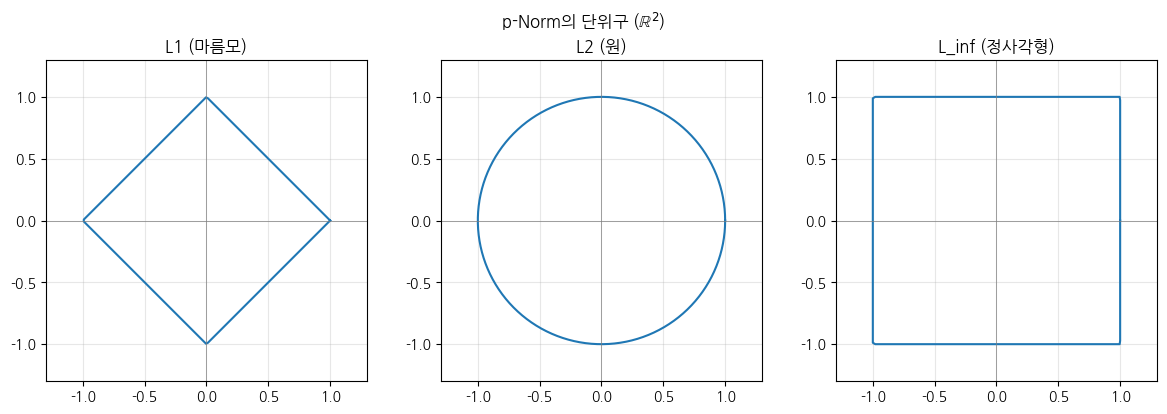

관찰: L1은 꼭짓점이 좌표축 위(sparse 유도), L2는 모든 방향 균등.


In [7]:
# 0도부터 360도까지의 각도를 400개로 촘촘히 찍어, 원을 부드럽게 근사한다.
# 여기서 400은 '도(degree)'가 아니라 샘플 개수이며, 값이 클수록 곡선이 더 매끈해진다.
theta = np.linspace(0, 2 * np.pi, 400)
# 각도 theta를 (cos(theta), sin(theta))로 바꾸면 반지름 1인 단위원 위의 점이 된다.
circle = np.stack([np.cos(theta), np.sin(theta)])  # 2 × 400 단위 원

# 세 가지 노름(L1, L2, L∞)에 대해 같은 점들을 어떻게 다른 단위구로 바꾸는지 나란히 비교한다.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, p, title in zip(axes, [1, 2, np.inf], ['L1 (마름모)', 'L2 (원)', 'L_inf (정사각형)']):
    # 원 위의 각 점 x를 그 점의 p-노름 ||x||_p 로 나누면, ||x / ||x||_p||_p = 1 이 된다.
    # 즉, 단위원의 점들을 p-단위구(boundary) 위의 점으로 정규화하는 과정이다.
    norms = np.array([my_norm(circle[:, i], p) for i in range(circle.shape[1])])
    pts = circle / norms
    # p-단위구의 경계선을 이어 그리면, 노름에 따라 모양이 어떻게 달라지는지 볼 수 있다.
    ax.plot(pts[0], pts[1])
    # 축 비율을 같게 맞춰야 원이 찌그러지지 않고, x/y 범위를 고정해야 세 그림을 공정하게 비교할 수 있다.
    ax.set_aspect('equal'); ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    # 보조 격자와 제목을 넣어 각 노름의 기하학적 차이를 읽기 쉽게 만든다.
    ax.grid(True, alpha=0.3); ax.set_title(title)
    # 좌표축을 함께 그려서 마름모/원/정사각형이 어느 방향으로 뻗는지 확인한다.
    ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
plt.suptitle('p-Norm의 단위구 ($\\mathbb{R}^2$)')
plt.tight_layout(); plt.show()
print('관찰: L1은 꼭짓점이 좌표축 위(sparse 유도), L2는 모든 방향 균등.')

## 4. Definition: Dot product·각도 (정의 2.2·2.3)

### 정의 2.2 (Dot product)
$$\mathbf{u} \cdot \mathbf{v} := \sum_{i=1}^n u_i v_i \;\in\; \mathbb{R} \qquad (=\mathbf{u}^\top \mathbf{v} = \langle \mathbf{u}, \mathbf{v} \rangle)$$

### Norm과의 관계
$$\mathbf{u} \cdot \mathbf{u} = \sum u_i^2 = \|\mathbf{u}\|_2^2 \quad\Rightarrow\quad \ell_2\text{ Norm은 Dot product에서 유도된다.}$$

### 정의 2.3 (각도)
$\mathbf{u}, \mathbf{v} \ne \mathbf{0}$에 대해 $\cos\theta := \dfrac{\mathbf{u}\cdot\mathbf{v}}{\|\mathbf{u}\|_2\,\|\mathbf{v}\|_2}$. 이 정의가 정당하려면 $\cos\theta \in [-1, 1]$이 보장돼야 합니다 → Cauchy-Schwarz.

## 5. Theorem: Cauchy-Schwarz 부등식 (정리 2.1)

모든 $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$에 대해
$$|\mathbf{u} \cdot \mathbf{v}| \;\le\; \|\mathbf{u}\|_2\,\|\mathbf{v}\|_2, \qquad \text{등호} \iff \mathbf{u}, \mathbf{v}\text{ 평행}.$$

증명 골자(강의교안 C-4): $\|\mathbf{u} - t\mathbf{v}\|^2 \ge 0$이 모든 $t$에서 성립 → $t$ 이차식의 판별식 $\le 0$. 아래에서 **등호(평행) 조건**을 직접 확인합니다.

## 6. Definition: Cosine similarity (정의 2.4·2.5)

### 정의 2.5 (Cosine similarity)
$$\mathrm{cos\_sim}(\mathbf{u}, \mathbf{v}) := \cos\theta = \frac{\mathbf{u}\cdot\mathbf{v}}{\|\mathbf{u}\|_2\,\|\mathbf{v}\|_2} \;\in\; [-1, 1]$$
범위 $[-1,1]$ 보장 = Cauchy-Schwarz. **스케일 불변**: 방향만 반영하고 크기는 무시 → BERT·CLIP 임베딩 비교의 표준.

### 정의 2.4 (Orthogonal·직교)
$\mathbf{u}\cdot\mathbf{v} = 0$이면 두 Vector는 **Orthogonal** ($\theta = \pi/2$).

In [8]:
def my_dot(u, v):
    # 두 벡터의 같은 위치 성분끼리 곱한 뒤 모두 더한 값이 내적이다.
    # 즉, u·v = sum_i u_i v_i 를 코드로 옮긴 것이다.
    u = np.asarray(u, dtype=float); v = np.asarray(v, dtype=float)
    return float((u * v).sum())


def my_cosine_similarity(u, v):
    # cosine similarity = (u·v) / (||u||_2 ||v||_2)
    # 방향의 유사도를 보기 위해, 내적을 두 벡터의 길이로 정규화한다.
    return my_dot(u, v) / (my_norm(u, 2) * my_norm(v, 2))


# Dot product·Norm 관계·각도
# a와 b의 내적을 직접 계산한 값과 np.dot의 값을 비교한다.
# 내적은 두 벡터가 같은 방향 성분을 얼마나 공유하는지 나타내는 스칼라다.
print(f'a·b = {my_dot(a, b):.4f}  (np.dot={np.dot(a, b):.4f})')
# a·a = ||a||^2 이므로, 같은 벡터와의 내적은 자기 길이의 제곱이 된다.
print(f'a·a = {my_dot(a, a):.4f},  ||a||^2 = {my_norm(a, 2) ** 2:.4f}   → u·u = ||u||^2')
# cosine similarity는 두 벡터 사이 각도의 코사인값이다.
# 값을 arccos에 넣으면 실제 각도 theta를 복원할 수 있다.
cos_ab = my_cosine_similarity(a, b)
print(f'cos(a, b) = {cos_ab:.4f}  → theta = {np.degrees(np.arccos(cos_ab)):.1f}도')

# Cosine의 스케일 불변: 같은 방향이면 길이가 달라도 코사인 유사도는 같다.
# d1은 짧은 벡터, d2는 같은 방향으로 10배 늘린 벡터다.
d1 = np.array([1., 1., 0., 0.]); d2 = np.array([10., 10., 0., 0.])
# 유클리드 노름은 길이 차이를 크게 반영하므로 두 벡터가 멀다고 본다.
# 반면 cosine similarity는 방향만 보므로 두 벡터를 사실상 같은 방향으로 본다.
print(f'\n||d1-d2|| = {my_norm(d1 - d2, 2):.2f} (유클리드론 "멀다")   vs   '
      f'cos_sim = {my_cosine_similarity(d1, d2):.2f} (코사인으론 "같다")')

a·b = -11.0000  (np.dot=-11.0000)
a·a = 30.0000,  ||a||^2 = 30.0000   → u·u = ||u||^2
cos(a, b) = -0.3667  → theta = 111.5도

||d1-d2|| = 12.73 (유클리드론 "멀다")   vs   cos_sim = 1.00 (코사인으론 "같다")


## 7. Application: MNIST 이미지 = $\mathbb{R}^{784}$ Vector

강의교안 D-1의 사실: **이미지 한 장 = $\mathbb{R}^d$ Vector**. 원본 MNIST는 28×28 → $\mathbb{R}^{784}$입니다. 실제 28×28 데이터를 불러와 두 이미지 비교와 **Cosine similarity 기반 이미지 검색**까지 해 봅니다.

In [9]:
from sklearn.datasets import fetch_openml

# 실제 MNIST를 내려받는다. 이름 'mnist_784'는 28×28 이미지를 이미 784차원 벡터로 펼쳐 둔 형태라는 뜻이다.
# 픽셀 값은 0~255이고, Colab에서 처음 한 번만 수십 초 걸린 뒤 캐시된다.
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
# 전체 7만 장은 최근접 검색에 무겁다. 실습 속도를 위해 앞 5000장만 사용한다.
X = mnist.data.astype(float)[:5000]     # (5000, 784): 각 행이 이미지 1장을 펼친 R^784 벡터
y = mnist.target.astype(int)[:5000]     # (5000,): 각 이미지의 정답 숫자(0~9)
# 같은 데이터를 28×28로 되돌린 버전. 거리·유사도 계산은 X(펼친 벡터)로, 화면 출력은 X_img(2D)로 한다.
X_img = X.reshape(-1, 28, 28)

print(f'사용 이미지: {X.shape[0]}장, 28×28 → Flatten R^{X.shape[1]}, 레이블 {np.unique(y)}')

사용 이미지: 5000장, 28×28 → Flatten R^784, 레이블 [0 1 2 3 4 5 6 7 8 9]


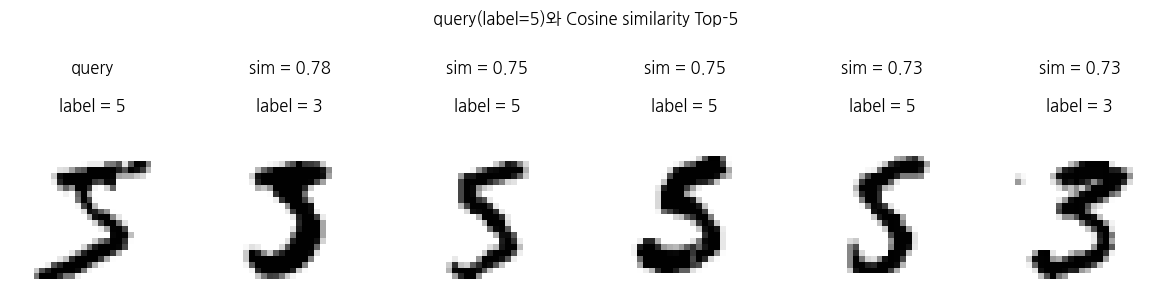

Top-5 중 같은 숫자 비율: 60%


In [20]:
# 쿼리와 가장 비슷한 이미지 Top-5를 찾는다.
# X는 앞 셀에서 불러온 MNIST 데이터 행렬이고, 각 행은 이미지 1장을 펼친 벡터다.
# X_img는 그 벡터를 다시 28×28 이미지로 되돌린 버전이다.
# 먼저 모든 이미지를 행 단위로 정규화한다. 각 벡터의 길이를 1로 맞춰 두면, 픽셀 개수나 진하기 같은 '크기' 차이를 빼고 모양만 비교할 수 있다.
# 그래서 뒤에서 내적을 곧바로 cosine similarity로 해석할 수 있다.
# axis=1은 행마다 노름을 구한다는 뜻이고, keepdims=True는 나눗셈 모양을 맞추기 위한 옵션이다.
Xn = X / np.linalg.norm(X, axis=1, keepdims=True)   # 각 이미지 벡터의 길이를 1로 맞춘다

def top_k_similar(qi, k=5):
    # 정규화된 벡터끼리의 내적은 cosine similarity가 된다.
    # @ 는 행렬곱 연산자다. Xn의 모든 행과 쿼리 이미지 Xn[qi]를 한 번에 곱해서 각 이미지의 점수를 만든다.
    sims = Xn @ Xn[qi]
    # 점수가 큰 순서대로 정렬한다.
    order = np.argsort(-sims)
    # 자기 자신은 제외하고 가장 비슷한 k개만 뽑는다.
    return [j for j in order if j != qi][:k], sims

qi = 0
neigh, sims = top_k_similar(qi, k=5)

# 쿼리 1장과 가장 비슷한 5장을 나란히 보여준다.
fig, axes = plt.subplots(1, 6, figsize=(12, 2.8))
axes[0].imshow(X_img[qi], cmap='gray_r')
axes[0].set_title(f'query\n\nlabel = {y[qi]}', pad=16)
axes[0].axis('off')
for ax, j in zip(axes[1:], neigh):
    ax.imshow(X_img[j], cmap='gray_r')
    ax.set_title(f'sim = {sims[j]:.2f}\n\nlabel = {y[j]}', pad=16)
    ax.axis('off')
plt.suptitle(f'query(label={y[qi]})와 Cosine similarity Top-5', y=1.08)
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()

# Top-5 안에 같은 숫자가 얼마나 섞였는지만 간단히 확인한다.
acc = np.mean([y[j] == y[qi] for j in neigh])
print(f'Top-5 중 같은 숫자 비율: {acc:.0%}')

## 8. 연습 (자가 점검)

1. **등호 조건**: $\mathbf{u} \in \mathbb{R}^5$를 임의로 잡고 $\mathbf{v} = c\,\mathbf{u}$로 두면 Cauchy-Schwarz가 등호가 됨을 확인하고, $c$의 부호에 따라 cosine similarity가 어떻게 달라지는지 보세요.
2. **최근접 검색 확장**: 위 `top_k_similar`에서 쿼리 인덱스 `qi`를 바꿔 가며 Top-5의 라벨 일치율을 비교해 보세요. 어떤 숫자가 헷갈리기 쉬운가요? (예: 4↔9, 3↔5)
3. **평행사변형 법칙**: $\|\mathbf{u}+\mathbf{v}\|^2 + \|\mathbf{u}-\mathbf{v}\|^2 = 2(\|\mathbf{u}\|^2+\|\mathbf{v}\|^2)$를 종이로 증명한 뒤 NumPy로 확인하세요.

## 9. 정리

| 번호 | 내용 |
|---|---|
| 정의 2.1 | Euclidean Norm $\lVert\mathbf{x}\rVert_2 = \sqrt{\sum x_i^2}$ + 일반화 $\ell_p$ |
| 정의 2.2 | Dot product $\mathbf{u}\cdot\mathbf{v} = \sum u_i v_i$ |
| 정리 2.1 | Cauchy-Schwarz: $\lvert \mathbf{u}\cdot\mathbf{v}\rvert \le \lVert\mathbf{u}\rVert\,\lVert\mathbf{v}\rVert$ |
| 정의 2.3 | 각도 $\cos\theta = \mathbf{u}\cdot\mathbf{v}/(\lVert\mathbf{u}\rVert\lVert\mathbf{v}\rVert)$ |
| 정의 2.4 | Orthogonal: $\mathbf{u}\cdot\mathbf{v} = 0$ |
| 정의 2.5 | Cosine similarity $= \cos\theta \in [-1, 1]$ |

- Norm·Dot product·Cosine similarity는 NumPy 기본 연산으로 한 줄씩 구현된다.
- 단위구 모양은 $p$에 따라 마름모·원·정사각형으로 달라진다.
- Cauchy-Schwarz가 cosine similarity의 범위 $[-1,1]$과 삼각부등식을 보장한다.
- 실제 MNIST(28×28, $\mathbb{R}^{784}$)에서 Cosine similarity 최근접 검색이 같은 숫자를 잘 찾아낸다.

> **응용 예고**: 3회차에서 Matrix·Vector 곱으로 여러 이미지를 한 번에 변환한다.